## 1. YOLO

**Contents:** 
1. YOLO
2. Quick Start
3. Output Data
4. Input/Output Formats
5. Pretrained Models
6. Architecture
7. NMS-free Inference
8. Fine-tuning
9. MuSGD

---

The **YOLO** (You Only Look Once) family is the most popular series of **real-time object detection** models in computer vision. It treats detection as a single regression problem, predicting bounding boxes and class probabilities directly from full images in one evaluation.

Since 2015, YOLO has split into two main ecosystems:

- **Official/maintained by Ultralytics** (the company behind the easy-to-use PyTorch implementation most people use today): YOLOv5 (2020), YOLOv8 (2023), YOLO11 (2024), YOLO26 (January 2026 — **current latest & recommended for most users**).
- **Community / academic forks** (often research-oriented, released on arXiv + GitHub): YOLOv3/v4 (original Darknet), YOLOv6 (Meituan), YOLOv7, YOLOv9, YOLOv10 (Tsinghua), YOLOv12 (attention-heavy, 2025), YOLO-NAS (Deci AI), PP-YOLOE (Baidu), YOLO-World (open-vocabulary), etc.

### 1.1 Main Branches & Community vs Ultralytics

- **Ultralytics lineage** (`pip install ultralytics`) — production-focused, unified API, excellent docs, multi-task support (detect + segment + pose + classify + OBB + track), active maintenance, easy export (ONNX, TensorRT, CoreML, TFLite, etc.), AGPL-3.0 license (open-source but copyleft — commercial/closed-source use often requires paid enterprise license from Ultralytics).
- **Community forks** — usually Apache-2.0 or MIT (more permissive), but often single-task (mostly detection), less polished tooling, slower updates, potential instability on edge/CPU. Great for research or when you need bleeding-edge ideas (e.g., attention in YOLOv12, quantization in YOLOv10).

As of March 2026, for **most people starting or deploying**, stick to **Ultralytics YOLO26** (or YOLO11 for very stable production). Community versions like YOLOv12 are powerful on GPU but heavier on CPU/edge and less mature in ecosystem.

**Key features:** end-to-end **NMS-free** inference (cleaner & faster exports), optimized for edge/low-power devices, supports detection + segmentation + pose + classification + oriented bounding boxes (OBB), uses modern training tricks like **MuSGD** optimizer.

**Install Ultralytics** (YOLO26 + all helpers):
```
pip install -U ultralytics
```

In [14]:
import ultralytics
ultralytics.checks()


Ultralytics 8.4.19 🚀 Python-3.11.14 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 3771MiB)
Setup complete ✅ (20 CPUs, 38.9 GB RAM, 314.6/318.4 GB disk)


## 2. Quick Start

### 2.1 Minimum Example — Inference with Pre-trained Model (PyTorch)

This is the fastest way to see YOLO working (object detection).


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /home/behnam/workspace/PyTorchTutorial/object_detection/bus.jpg: 640x480 4 persons, 1 bus, 10.7ms
Speed: 1.9ms preprocess, 10.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 480)


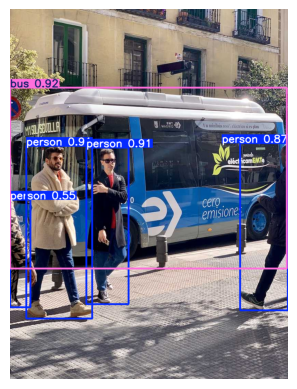

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([5., 0., 0., 0., 0.], device='cuda:0')
conf: tensor([0.9238, 0.9126, 0.9054, 0.8702, 0.5518], device='cuda:0')
data: tensor([[0.0000e+00, 2.2937e+02, 8.0608e+02, 7.5712e+02, 9.2380e-01, 5.0000e+00],
        [2.2246e+02, 4.0493e+02, 3.4541e+02, 8.6165e+02, 9.1259e-01, 0.0000e+00],
        [4.7688e+01, 3.9931e+02, 2.3932e+02, 9.0302e+02, 9.0542e-01, 0.0000e+00],
        [6.7065e+02, 3.9153e+02, 8.0981e+02, 8.7901e+02, 8.7015e-01, 0.0000e+00],
        [1.2939e-01, 5.5669e+02, 5.9995e+01, 8.7010e+02, 5.5176e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([5, 6])
xywh: tensor([[403.0388, 493.2430, 806.0776, 527.7502],
        [283.9343, 633.2883, 122.9417, 456.7262],
        [143.5041, 651.1644, 191.6320, 503.7135],
        [740.2286, 635.2670, 139.1598, 487.4781],
        [ 30.0623, 713.3937,  59.8657, 313.4067]], device='cuda:0')
xywhn: tensor([[0.4976, 0.4567, 0.99

In [15]:
from ultralytics import YOLO

# 1. Load a pretrained model (nano = fastest & lightest, download happens automatically)
model = YOLO("yolo26n.pt")          # nano version (~3–4 MB)
# alternatives: yolo26s.pt, yolo26m.pt, yolo26l.pt, yolo26x.pt (larger = more accurate but slower)

# 2. Run inference on an image (URL, local path, or numpy array)
results = model("https://ultralytics.com/images/bus.jpg")   # or "path/to/your/image.jpg"

# 3. Show / process results
# results[0].plot() returns BGR numpy array - use matplotlib to display in notebook
%matplotlib inline
import matplotlib.pyplot as plt
img = results[0].plot()
plt.imshow(img[:, :, ::-1])  # BGR to RGB
plt.axis("off")
plt.show()

# Quick look at structured output
for result in results:
    print(result.boxes)              # bounding boxes + confidence + class id

    # Most useful fields:
    # result.boxes.xyxy          → tensor of [x1,y1,x2,y2]
    # result.boxes.conf          → confidence scores
    # result.boxes.cls           → class indices (0 = person, 2 = car, etc — COCO classes)
    # result.names               → dict {0: 'person', 1: 'bicycle', ...}

## 3. Output Data Explained

After running `model(source)`, you get a list of `Results` objects (one per image).

Main attributes:

- `results[0].boxes`          → `Boxes` object  
  - `.xyxy`      → (N,4) tensor — absolute coordinates [x1,y1,x2,y2]  
  - `.xywh`      → center-x, center-y, width, height  
  - `.conf`      → (N,) confidences [0–1]  
  - `.cls`       → (N,) class indices (integers)  
  - `.data`      → (N,6) tensor with all above + class in one place

- `results[0].names`          → {int: str} class name mapping

- `results[0].orig_img`       → original image as numpy array

- For segmentation: `results[0].masks` (if using `yolo26n-seg.pt`)

- For pose: `results[0].keypoints`

Very convenient methods:

```python
results[0].show()             # display annotated image
results[0].save(filename="output.jpg")   # save annotated image
results[0].plot()             # matplotlib figure
```

### 3.1 Quick Training Example (custom data or COCO8 toy dataset)

```python
from ultralytics import YOLO

model = YOLO("yolo26n.pt")           # start from pretrained weights

# Train (example with small COCO8 subset — 8 images — for testing)
results = model.train(
    data="coco8.yaml",               # Ultralytics auto-downloads this toy dataset
    epochs=30,
    imgsz=640,
    device=0                         # 0 = GPU, "cpu" = cpu
)
```

For your own dataset → prepare it in **YOLO format**:

```
dataset/
├── images/
│   ├── train/
│   │   ├── img1.jpg
│   │   └── img2.jpg
│   └── val/
│       ├── img1.jpg
│       └── img2.jpg
├── labels/
│   ├── train/          ← .txt files (one per image, same base name)
│   │   ├── img1.txt
│   │   └── img2.txt
│   └── val/
│       ├── img1.txt
│       └── img2.txt
└── data.yaml
```

Each `.txt` file:  
`class_id center_x center_y width height`  (normalized 0–1)

Example `img1.txt` (one object, class 0 = cat, box at center):
```
0 0.5 0.5 0.2 0.3
```

`data.yaml` example:
```yaml
path: /home/user/project/dataset
train: images/train
val: images/val

nc: 2
names: ['cat', 'dog']
```

Then: `model.train(data="data.yaml", epochs=100, imgsz=640)`


## 4. Input/Output Formats & Use Cases

### 4.1 Input / Output Formats (Ultralytics Style — Same Across v8/11/26)

- **Input**:
  - Images: file path, URL, numpy array, PIL Image, video, directory, YouTube link, webcam (0), RTSP stream.
  - Shape: usually square 640×640 (letterboxed), but supports rectangular with imgsz=(640,480), batch inference.
  - Preprocessing: auto-resized + normalized (mean=[0,0,0], std=[1,1,1] or ImageNet stats).

- **Output** (Results object — very convenient):
  - List of Results (one per image).
  - For detection: `result.boxes` → xyxy (N×4), conf (N), cls (N), names dict {0: 'person', ...}.
  - Segmentation: + `result.masks` (binary or prob masks).
  - Pose: + `result.keypoints`.
  - Oriented BB (OBB): rotated boxes (cx,cy,w,h,angle).
  - Easy access: `.show()`, `.save()`, `.plot()`, `.boxes.data` (N×6 or more tensor).

### 4.2 Tasks Supported (Ultralytics YOLO26/11)

- **Object Detection** — bounding boxes + class + confidence (classic YOLO).
- **Instance Segmentation** — per-object pixel masks (like Mask R-CNN but real-time).
- **Pose Estimation** — keypoints (person pose, hand landmarks, etc.).
- **Classification** — whole-image class (like ResNet but YOLO backbone).
- **Oriented Bounding Boxes (OBB)** — rotated boxes (great for aerial/satellite, text, logistics).
- **Tracking** — ByteTrack/BoT-SORT integration (multi-object tracking).
- **Open-vocabulary / Zero-shot** (YOLO-World variants) — detect via text prompt like "red car" without retraining.

### 4.3 What YOLO is Best For

- Real-time applications (30–200+ FPS on modern GPU, 10–60 FPS on CPU/edge).
- Edge devices (Jetson, Raspberry Pi with accel, phones, embedded — especially YOLO26).
- Production deployment (easy export, Ultralytics HUB for cloud training).
- Multi-task projects (one model does detect + segment + pose).
- Custom datasets (easy training with Roboflow integration, YAML format).
- Domains: autonomous driving, surveillance, robotics, retail (people counting), agriculture (crop/fruit detection), medical imaging (real-time tool detection), drones/aerial.

### 4.4 When to Avoid YOLO (or Choose Alternatives)

- You need highest possible accuracy and don't care about speed → use **DETR**, **RT-DETR**, **Grounding DINO**, ** Florence-2**, or large ViT-based models.
- Extremely small objects in dense scenes → specialized small-object models (e.g., some YOLOv12 variants or Swin Transformer detectors) often beat standard YOLO.
- Open-vocabulary without fine-tuning → Grounding DINO, OWLv2, or YOLO-World (but YOLO-World is still YOLO-based).
- You want permissive license for closed-source commercial product → community forks (YOLOv10, v12) or models like RT-DETR (Apache).
- Very large images / panoramic → sliding window or other tiled approaches (YOLO can do it but not optimal out-of-box).
- Pure research on new architectures → community forks give more flexibility to modify.

Start with **YOLO26n.pt** or **YOLO26s.pt** — load with one line, run inference, see results immediately. The ecosystem (docs, Discord, GitHub issues) is extremely helpful for beginners.

## 5. Pretrained Models

### 5.1 Classes per Task (Pretrained Datasets)

The official **Ultralytics YOLO** models (YOLO26, YOLO11, etc.) are pretrained on different datasets depending on the task. Here's the breakdown for the number of classes:

- **Object Detection** (most common use, models like `yolo26n.pt`, `yolo26s.pt`, etc.):  
  Pretrained on the **COCO dataset**, which has **80 classes**.  
  These include everyday objects like person, car, bicycle, dog, cat, bottle, chair, etc. (full list: person, bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light, fire hydrant, stop sign, parking meter, bench, bird, cat, dog, horse, sheep, cow, elephant, bear, zebra, giraffe, backpack, umbrella, handbag, tie, suitcase, frisbee, skis, snowboard, sports ball, kite, baseball bat, baseball glove, skateboard, surfboard, tennis racket, bottle, wine glass, cup, fork, knife, spoon, bowl, banana, apple, sandwich, orange, broccoli, carrot, hot dog, pizza, donut, cake, chair, couch, potted plant, bed, dining table, toilet, tv, laptop, mouse, remote, keyboard, cell phone, microwave, oven, toaster, sink, refrigerator, book, clock, vase, scissors, teddy bear, hair drier, toothbrush).

- **Instance Segmentation** (`yolo26n-seg.pt` etc.): Also pretrained on COCO, **80 classes** (same as detection).

- **Pose Estimation** (`yolo26n-pose.pt` etc.): Pretrained on COCO keypoints, but focused on **1 class** ('person') with 17 keypoints.

- **Classification** (`yolo26n-cls.pt` etc.): Pretrained on ImageNet, **1000 classes**.

- **Oriented Bounding Boxes (OBB)**: Usually pretrained on datasets like DOTA, with **15 classes** (aerial/satellite specific, e.g., plane, ship, storage tank).

When you load a pretrained detection model like `YOLO("yolo26n.pt")`, it expects **nc=80** (number of classes) by default. If your custom dataset has a different number (e.g., 5 classes for cats/dogs/vehicles/etc.), Ultralytics automatically adapts the head during training — it transfers all backbone weights and reinitializes/adapts only the detection head for your new `nc`. You don't train fully from scratch; you still get strong transfer learning benefits from the shared backbone features.




### 5.2 Standard Tasks (Pretrained on COCO for detect/seg/pose, ImageNet for cls, DOTA-like for obb)


- **Detection** (object bounding boxes, 80 COCO classes)  
  `yolo26n.pt`  
  `yolo26s.pt`  
  `yolo26m.pt`  
  `yolo26l.pt`  
  `yolo26x.pt`

- **Instance Segmentation** (detection + per-object masks)  
  `yolo26n-seg.pt`  
  `yolo26s-seg.pt`  
  `yolo26m-seg.pt`  
  `yolo26l-seg.pt`  
  `yolo26x-seg.pt`

- **Pose / Keypoints** (person pose estimation, 1 class + 17 keypoints)  
  `yolo26n-pose.pt`  
  `yolo26s-pose.pt`  
  `yolo26m-pose.pt`  
  `yolo26l-pose.pt`  
  `yolo26x-pose.pt`

- **Oriented Bounding Boxes (OBB)** (rotated boxes, great for aerial/satellite/text)  
  `yolo26n-obb.pt`  
  `yolo26s-obb.pt`  
  `yolo26m-obb.pt`  
  `yolo26l-obb.pt`  
  `yolo26x-obb.pt`

- **Classification** (whole-image classification, 1000 ImageNet classes)  
  `yolo26n-cls.pt`  
  `yolo26s-cls.pt`  
  `yolo26m-cls.pt`  
  `yolo26l-cls.pt`  
  `yolo26x-cls.pt`

### 5.3 Additional Variants: YOLOE-26 (Open-Vocabulary / Zero-Shot Segmentation)
These are newer open-vocabulary models (text-prompt based, like "detect red car" without retraining). They come in standard and prompt-free (pf) versions.

- `yoloe-26n-seg.pt`  
  `yoloe-26s-seg.pt`  
  `yoloe-26m-seg.pt`  
  `yoloe-26l-seg.pt`  
  `yoloe-26x-seg.pt`  

- Prompt-free versions:  
  `yoloe-26n-seg-pf.pt`  
  `yoloe-26s-seg-pf.pt`  
  `yoloe-26m-seg-pf.pt`  
  `yoloe-26l-seg-pf.pt`  
  `yoloe-26x-seg-pf.pt`

That's roughly **25 core models + 10 YOLOE variants** = **35 total** pretrained checkpoints. All are auto-downloaded from GitHub releases when you first use them (via `YOLO("yolo26n.pt")` or similar).

### 5.4 List Models Programmatically

Ultralytics does **not** provide a built-in method like `YOLO.list_models()` or an API to enumerate all official pretrained names (as of 2026). The names are hardcoded/documented, and the library expects you to know/pass the exact string (it will download if missing).

However, you can do these practical things in code:

1. **Load any model** (safest & recommended way — it auto-downloads):
   ```python
   from ultralytics import YOLO

   # Examples
   model = YOLO("yolo26n.pt")         # detection nano
   model = YOLO("yolo26n-seg.pt")     # segmentation
   model = YOLO("yolo26x-cls.pt")     # classification xlarge
   model = YOLO("yoloe-26m-seg.pt")   # open-vocab seg
   ```

2. **Check model info** after loading (shows architecture, tasks supported, etc.):
   ```python
   model = YOLO("yolo26n.pt")
   print(model)                # or model.info() for detailed summary
   ```

3. **Manual list in your code** (you can hardcode the names yourself for convenience):
   ```python
   yolo26_models = [
       "yolo26n.pt", "yolo26s.pt", "yolo26m.pt", "yolo26l.pt", "yolo26x.pt",
       "yolo26n-seg.pt", "yolo26s-seg.pt", "yolo26m-seg.pt", "yolo26l-seg.pt", "yolo26x-seg.pt",
       "yolo26n-pose.pt", "yolo26s-pose.pt", "yolo26m-pose.pt", "yolo26l-pose.pt", "yolo26x-pose.pt",
       "yolo26n-obb.pt", "yolo26s-obb.pt", "yolo26m-obb.pt", "yolo26l-obb.pt", "yolo26x-obb.pt",
       "yolo26n-cls.pt", "yolo26s-cls.pt", "yolo26m-cls.pt", "yolo26l-cls.pt", "yolo26x-cls.pt",
       # YOLOE variants
       "yoloe-26n-seg.pt", "yoloe-26s-seg.pt", # ... etc.
   ]

   # Example: try loading one by one or pick based on task/size
   task = "seg"  # or "cls", "pose", etc.
   size = "n"
   model_name = f"yolo26{size}-{task}.pt" if task != "" else f"yolo26{size}.pt"
   model = YOLO(model_name)
   ```

For the most up-to-date/full list (including any new experimental ones), always check:
- https://docs.ultralytics.com/models/yolo26/  
- https://github.com/ultralytics/assets/releases (where the .pt files are hosted)  
- or the task-specific pages (e.g., https://docs.ultralytics.com/tasks/segment/).


## 6. Architecture: Anchor-Based vs Anchor-Free

The core idea of **YOLO** (across versions) is to divide the input image into a **grid** of cells (e.g., 640×640 image → often 80×80, 40×40, 20×20 grids at different scales in modern versions). Each grid cell is responsible for detecting objects whose **center** falls inside that cell.

This grid-based approach has stayed consistent from YOLOv1 to the latest YOLO26, but the way bounding boxes are **predicted** within each cell has evolved dramatically — from **anchor-based** (older) to **anchor-free** (modern Ultralytics YOLOv8+ including YOLO26).

### 6.1 Anchor-Based Detection (YOLOv1–v5 era, also YOLOv3/v4/v7 community versions)

**How the grid + anchors work together:**

- Image → divided into **S × S grid** (e.g., 13×13 in YOLOv3, or multi-scale like 80×80 + 40×40 + 20×20 in later versions).
- **Each grid cell** predicts:
  - **B bounding boxes** (B = number of anchors per cell, usually 3–9 depending on version).
  - For **each** of those B boxes: 5 values = (x, y, w, h, objectness/confidence)
    - **x, y**: offset (0–1) from the **top-left corner of the grid cell** (sigmoid-activated so stays within cell).
    - **w, h**: width & height — but **not absolute**; instead **scale factors** relative to a predefined **anchor box** (e.g., w = predicted_width × anchor_width).
    - **objectness**: how confident there is an object (Pr(Object) × IoU).
  - Plus class probabilities (one set per cell, shared across the B boxes in that cell).
- **Anchor boxes** = predefined box shapes (width/height pairs), usually 3–9 per detection head, calculated via k-means clustering on your dataset's ground-truth boxes (common shapes like tall/narrow for people, wide for cars).
  - They are **not placed at every pixel** — only **one set of anchors per grid cell**.
  - Example: for a cell responsible for a person, the model might predict offsets/scales on a tall anchor (e.g., 1:3 aspect ratio), while ignoring square anchors.

**Why anchors were introduced (YOLOv2+):**
- Early YOLOv1 predicted boxes directly (no anchors) → struggled with varying sizes/aspect ratios because each cell could only predict fixed-size boxes well.
- Anchors act as **strong priors** → help the model specialize (one anchor for small objects, one for medium, one for large/wide/tall).

**Downsides:**
- Need to tune/cluster anchors (hyperparameter-sensitive).
- Many redundant predictions (multiple anchors per cell detect same object → heavy NMS needed).
- Can miss unusual shapes or very small/large objects if anchors don't match dataset well.
- Complicates training (assign ground-truth to best-matching anchor via IoU).

### 6.2 Anchor-Free Detection (YOLOv8, YOLO11, YOLO26, and most modern Ultralytics versions)

**Key change (starting ~YOLOv8):**
No more predefined anchor shapes. The model **directly predicts** the bounding box without referring to any prior box template.

**How grid + anchor-free works:**

- Still uses the **same grid** (multi-scale feature maps: e.g., P3/80×80, P4/40×40, P5/20×20 for small/medium/large objects).
- **Each grid cell** (now often called a "feature point" or "pixel" on the feature map) predicts **exactly one bounding box** (in the main detection branch).
- Prediction per grid cell/location:
  - **Center location**: directly predicts the **center coordinates** (cx, cy) of the object — usually as offsets within the cell (sigmoid to keep it local), but interpreted as the true object center (which must lie in this cell).
  - **Box size**: directly predicts **absolute width & height** (or distances to four sides like left/right/top/bottom in some designs, e.g., similar to FCOS).
  - **Objectness/confidence** score.
  - Class probabilities.
- No "B" multiple predictions per cell — usually **one direct regression** per location.
- Modern heads often use **distributional regression** (e.g., Distribution Focal Loss or similar) to predict box coords more accurately (soft distribution over possible values instead of single point estimate).

**Advantages of going anchor-free (why Ultralytics switched):**
- Simpler pipeline → no anchor clustering/tuning needed.
- Fewer predictions overall → less redundant boxes → lighter/faster NMS (and eventually NMS-free in YOLO26+).
- Better generalization → no bias from hand-crafted priors; model learns shapes directly from data.
- Easier to handle varied aspect ratios/sizes (especially extreme ones).
- Cleaner exports (ONNX/TensorRT/CoreML) and edge deployment (less logic in post-processing).
- Often slightly higher accuracy in practice for the same backbone.

**Trade-offs:**
- Training can be trickier initially (needs good positive/negative assignment strategies, like task-aligned assigner in Ultralytics).
- Relies more on data augmentation and strong loss design to handle size/scale variety.

### 6.3 Quick Visual Summary

**Anchor-based (older YOLO):**
```
Image grid cell → 3 anchors (tall, wide, square)
                   ↓
              Predict offsets & scales relative to each anchor
                   ↓
         → 3 candidate boxes per cell (then NMS)
```

**Anchor-free (YOLOv8/11/26):**
```
Image grid cell → 1 direct prediction
                   ↓
      Predict absolute center + width/height (or l/t/r/b distances)
                   ↓
         → 1 clean box per positive location (much less overlap)
```

In code with Ultralytics YOLO26, you don't see any of this — it's all hidden in the model head. You just load `yolo26n.pt` (anchor-free by design) and get clean `.boxes.xyxy` directly.

If you'd like diagrams (I can describe where to look or suggest searching for "YOLO anchor-based vs anchor-free visualization"), or want to dive into how label assignment differs in training, just say!

## 7. End-to-end NMS-free Inference

**End-to-end NMS-free inference** is a major architectural advancement in modern real-time object detection models (especially in the **YOLO** family from Ultralytics). It means the neural network directly outputs the final set of cleaned, non-overlapping bounding boxes (and classes/confidences) — without needing any separate post-processing step like **Non-Maximum Suppression (NMS)** at the end.

### 7.1 What is NMS and why was it needed?

In classic YOLO (up to YOLOv11, YOLOv8, YOLOv5, etc.):

1. The model predicts **thousands** of candidate bounding boxes per image (often 3000–8400+ proposals from the grid + anchors or anchor-free cells).
2. Many of these overlap heavily on the same object (different cells/predictions seeing slightly different parts of the same person/car/etc.).
3. The model outputs raw predictions with high confidence for all overlapping ones.
4. **NMS** (Non-Maximum Suppression) is then applied as a post-processing filter:
   - Sort boxes by confidence
   - Keep the highest-confidence box
   - Suppress (remove) any other box that overlaps it too much (IoU > threshold, usually 0.45–0.7)
   - Repeat for next highest, etc.
5. This step is non-differentiable → cannot be trained end-to-end with the network.
6. It adds latency (especially on CPU/edge), can be inconsistent across hardware, and sometimes removes correct boxes in dense/crowded scenes.

This made the full pipeline **not truly end-to-end** — the model forward pass was fast, but you still needed extra code/logic for NMS.

### 7.2 What "end-to-end NMS-free inference" changes

Starting with **YOLOv10** (2024, Tsinghua + Ultralytics packaging) and perfected in **YOLO26** (2026, Ultralytics flagship), the model is redesigned so that:

- During **training**, special label assignment strategies are used:
  - **One-to-many** head (allows multiple positive samples per GT for rich supervision, like before)
  - **One-to-one** head (forces the model to learn exactly one best/confident prediction per ground-truth object)
  - Consistent dual assignments + matching metrics teach the network to avoid duplicates internally.
- During **inference**, only the **one-to-one head** is used → the model directly outputs a small set of high-quality, non-overlapping boxes (one per detected object, no heavy duplicates).
- **No NMS needed anymore** — the final detections come straight from the network forward pass.

YOLO26 takes this even further:
- Removes **Distribution Focal Loss (DFL)** (which was good for regression but slow on CPU)
- Uses simpler losses + optimizations (MuSGD optimizer, progressive loss scheduling, etc.)
- Native end-to-end design → especially fast and stable on **edge devices**, **CPU**, and **low-power hardware** (Jetson, Raspberry Pi with accel, phones, embedded systems)

### 7.3 Benefits of end-to-end NMS-free (especially in YOLO26)

- **Faster inference** — 30–50% lower latency in many cases (especially CPU/edge), more deterministic timing (no variable NMS loops depending on how many overlaps)
- **Simpler code & deployment** — No need to implement/tune NMS (IoU threshold, soft-NMS variants, etc.). Just run `model.predict()` and get clean results. Exports (ONNX, TensorRT, TFLite, CoreML) are cleaner and more consistent.
- **Better edge/embedded performance** — NMS was a bottleneck on weak hardware; now removed.
- **More stable behavior** — No surprises from NMS suppressing correct boxes in crowds.
- Still keeps real-time speeds (often higher FPS than previous YOLOs at similar accuracy).

### 7.4 Trade-offs

- Slightly more complex training setup behind the scenes (dual heads/assignments), but Ultralytics hides this — you train normally with `model.train()`.
- On very high-end GPUs where NMS was already negligible, the speedup is smaller (but still present).
- Early NMS-free models (like initial YOLOv10) sometimes needed careful tuning; YOLO26 is production-mature.

### 7.5 Quick example (YOLO26 — truly NMS-free)

```python
from ultralytics import YOLO

model = YOLO("yolo26n.pt")          # NMS-free by design
results = model("bus.jpg")          # direct final boxes, no .postprocess_nms() needed
results[0].show()                   # clean output immediately
```

In short:  
**End-to-end NMS-free inference** = the model itself learns to suppress duplicates during training → at inference time you get ready-to-use detections straight from the forward pass, skipping the old post-processing step entirely.

This is one of the biggest reasons **YOLO26** is currently the go-to for edge/production real-time detection in 2026.

## 8. Fine-tuning

### 8.1 When Should You Fine-Tune YOLO?

Fine-tune (i.e., run `.train()` on a pretrained `.pt` model) in these situations:

- **Your objects are not (well) covered by the 80 COCO classes** → e.g., medical tools, specific industrial parts, custom products, drones detecting rare defects, agricultural crops/pests. Pretrained COCO won't detect your specific things reliably.
- **Domain shift** → even if classes overlap (e.g., "person" or "car"), your images differ a lot (aerial views, infrared, low-light surveillance, underwater, medical scans, synthetic data). Fine-tuning adapts to lighting, angles, resolution, background clutter.
- **You need higher accuracy on your specific data** → COCO mAP is general; your real-world use case often benefits from 10–100× more targeted training.
- **Small/medium custom dataset** (hundreds to thousands of images) → transfer learning from COCO weights gives much better starting point and faster convergence than training from scratch (`.yaml` only).
- **You want multi-task or specialized output** → e.g., add segmentation to detection, or train OBB for rotated objects.

**When you can often skip heavy fine-tuning**:
- Your use case matches COCO closely (general surveillance, everyday objects) → zero-shot inference on pretrained model is often good enough.
- Extremely large custom dataset (hundreds of thousands of images) → sometimes training from scratch (or with minimal pretraining) can outperform if data is very domain-specific.

Best practice: **Always start with a pretrained model** (`.pt`) unless you have millions of diverse images. Fine-tune for 50–300 epochs depending on dataset size.



### 8.2 Which Part of the Network Should You Fine-Tune?

In Ultralytics YOLO (YOLO26/YOLO11/etc.), the architecture is roughly:

- **Backbone** (early layers: feature extraction, general patterns like edges/textures/shapes) — pretrained on COCO/ImageNet-like data.
- **Neck** (feature fusion, like PAN/FPN) — mid-level.
- **Head** (detection/segmentation output layers: class scores, box regression) — most task-specific.

**Recommended strategies** (use the `freeze` argument in `.train()`):

1. **Full fine-tuning (recommended default for most cases)**  
   ```python
   model.train(data="your_data.yaml", epochs=100, imgsz=640)  # freeze=None (default)
   ```
   - Unfreeze everything → best results when you have decent data (500+ images per class).
   - Modern YOLO models converge fast; full fine-tuning often gives highest accuracy.

2. **Freeze backbone only (good for small datasets or fast experiments)**  
   ```python
   model.train(..., freeze=10)  # ~10 layers = backbone in most YOLO versions
   ```
   - Keeps general features frozen → trains mostly neck + head.
   - Very useful if your dataset is small (<500–1000 images total) to prevent catastrophic forgetting/overfitting.
   - Common starting point: freeze=10 (exact number can vary slightly by model version; check `model.summary()` or docs).

3. **Two-stage fine-tuning (advanced, often best for very small datasets)**  
   - Stage 1: Freeze backbone, train head/neck (e.g., freeze=10, 20–50 epochs, higher lr like 0.01–0.1).
   - Stage 2: Unfreeze all or partial (freeze=None or freeze=0–5), lower lr (0.001–0.01), train longer.
   - This mimics classic transfer learning: adapt head first, then gently tune features.

4. **Freeze more aggressively** (rare, for tiny datasets):  
   freeze=15–20 → leaves only final head layers trainable.

Quick check in code:
```python
from ultralytics import YOLO
model = YOLO("yolo26n.pt")
print(model)  # or model.info() to see layer indices
```

In practice:
- Start with full fine-tuning.
- If overfitting (val mAP plateaus or drops while train improves) or very small data → try freeze=10.
- Monitor val mAP / loss curves — the highest val mAP wins.


## 9. MuSGD Optimizer

**MuSGD** is a **new hybrid optimizer** introduced by Ultralytics specifically for **YOLO26** (and available in the Ultralytics library starting ~late 2025 / early 2026).

It's designed to make training more **stable**, **predictable**, and often **faster-converging** compared to classic optimizers like plain SGD or AdamW — especially useful for real-time object detection models on diverse datasets.

### 9.1 What does MuSGD stand for / combine?
- **Mu** → from **Muon** (a relatively new optimizer technique/paper from ~2025, arXiv:2502.16982)
- **SGD** → classic **Stochastic Gradient Descent** (with momentum)

So: **MuSGD = Muon + SGD hybrid**

- It blends:
  - The **simplicity**, **generalization power**, and **low memory usage** of traditional **SGD with momentum** (the long-time favorite in YOLO training)
  - Advanced momentum handling + **orthogonalization** techniques from **Muon** (which uses Newton-Schulz iterations to keep weight matrices well-conditioned / orthogonal during updates — originally developed and popularized in large language model (LLM) training)

### 9.2 Where does the inspiration come from?
The main spark is **Moonshot AI's Kimi K2** (a powerful Chinese LLM released around 2025), which used Muon-style optimization tricks to achieve very stable and efficient training at scale.  
Ultralytics took those LLM-era optimization ideas and adapted them into computer vision / convolutional networks → resulting in **MuSGD**.

### 9.3 Key benefits (as reported for YOLO26 training)
- **Faster convergence** — reaches good validation metrics in fewer epochs
- **More stable training curves** — less spiky/val loss explosions, especially on small or noisy custom datasets
- **Better generalization** — often helps models perform better on unseen data (reported in some blogs/papers)
- **Lower memory footprint** during training compared to heavy Adam-family optimizers or pure second-order methods
- Particularly shines on **edge-optimized models** (nano/small variants) and when training from pretrained weights

### 9.4 How to use it in Ultralytics YOLO (YOLO26 and later)
It's integrated natively and often selected **automatically** for YOLO26 models, but you can explicitly choose it:

```python
from ultralytics import YOLO

model = YOLO("yolo26n.pt")  # or yolo26s.pt etc.

# MuSGD is usually auto-selected for YOLO26, but you can force it:
results = model.train(
    data="coco8.yaml",          # or your custom data.yaml
    epochs=100,
    imgsz=640,
    optimizer="MuSGD",          # ← explicit choice (options: 'auto', 'SGD', 'MuSGD', 'AdamW', etc.)
    lr0=0.01,                   # typical starting LR for MuSGD / SGD-style
    momentum=0.937,             # common value
    device=0
)
```

Or via CLI:
```
yolo train data=coco8.yaml model=yolo26s.pt epochs=100 optimizer=MuSGD lr0=0.01
```

- Default behavior in recent Ultralytics versions: for YOLO26 models, `optimizer='auto'` often picks **MuSGD** because it's tuned for the new architecture.
- You can still fall back to `'SGD'` or `'AdamW'` if you want classic behavior or are comparing.

### 9.5 Quick Summary Table

| Aspect              | Classic SGD (momentum) | Adam/AdamW             | MuSGD (YOLO26)                          |
|---------------------|------------------------|------------------------|------------------------------------------|
| Memory usage        | Very low               | Higher                 | Low–medium (closer to SGD)               |
| Convergence speed   | Moderate               | Fast early, can plateau| Often faster & more consistent           |
| Stability           | Good but can be noisy  | Can be unstable at scale| High (LLM-inspired tricks)               |
| Generalization      | Strong                 | Sometimes weaker       | Strong (reported gains in papers/blogs)  |
| Best for            | Most CV tasks 2018–2024| Transformers/LLMs      | Modern YOLO (edge models, custom data)   |

In short: **MuSGD** is Ultralytics' way of bringing 2025-era **LLM training tricks** (Muon-style orthogonal + momentum updates) into **real-time vision models** — making YOLO26 train more reliably without extra complexity for the user.  
If you're training YOLO26, just try it with `optimizer='MuSGD'` (or 'auto') — many users report noticeably smoother runs and slightly better final mAP, especially on smaller datasets.